In [15]:
import os
import io
import time
import random
import zstandard as zstd
import chess.pgn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import onnx
import matplotlib.pyplot as plt

# --- НАСТРОЙКИ ---
DATA_FILE = "lichess_db_standard_rated_2017-01.pgn.zst"
OUTPUT_MODEL = "chess_model.onnx"
BEST_MODEL_PATH = "best_model.pth"

MAX_GAMES = 200000      # Количество партий для теста
BATCH_SIZE = 2048        # Размер батча
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
VAL_SPLIT = 0.02        # 2% на валидацию

USE_CUDA = True 

DEVICE = torch.device("cuda" if USE_CUDA and torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

# Маппинг фигур
PIECE_MAP = {
    'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
    'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11
}

def format_time(seconds):
    m, s = divmod(int(seconds), 60)
    return f"{m} мин {s} сек"

Используемое устройство: cuda


In [16]:
def board_to_tensor(board):
    tensor = torch.zeros((12, 8, 8), dtype=torch.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            symbol = piece.symbol()
            if symbol in PIECE_MAP:
                row = 7 - chess.square_rank(square)
                col = chess.square_file(square)
                tensor[PIECE_MAP[symbol], row, col] = 1.0
    return tensor

class ChessDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Проверка наличия файла
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Файл {DATA_FILE} не найден в текущей папке!")

print(f"Начало обработки: {DATA_FILE} (лимит {MAX_GAMES} партий)...")
start_parse = time.time()

train_data = []
val_data = []
games_processed = 0

dctx = zstd.ZstdDecompressor()
with open(DATA_FILE, 'rb') as f:
    with dctx.stream_reader(f) as reader:
        raw_text = reader.read().decode('utf-8', errors='ignore')

pgn_io = io.StringIO(raw_text)
del raw_text  # Освобождаем память от сырой строки

while games_processed < MAX_GAMES:
    game = chess.pgn.read_game(pgn_io)
    if game is None:
        break
    
    games_processed += 1
    if games_processed % 20000 == 0:
        elapsed = time.time() - start_parse
        print(f"Обработано: {games_processed} парт., Позиций: {len(train_data)+len(val_data)}, Время: {format_time(elapsed)}")

    result_str = game.headers.get("Result", "*")
    label = -1
    if result_str == "1-0": label = 0
    elif result_str == "1/2-1/2": label = 1
    elif result_str == "0-1": label = 2
    
    if label == -1: 
        continue

    board = game.board()
    for node in game.mainline_moves():
        board.push(node)
        if board.fullmove_number < 2: 
            continue
        
        tensor = board_to_tensor(board)
        if random.random() < VAL_SPLIT:
            val_data.append((tensor, label))
        else:
            train_data.append((tensor, label))

total_time = time.time() - start_parse
print(f"✅ Готово! Всего позиций: {len(train_data) + len(val_data)}")
print(f"   Train: {len(train_data)}, Val: {len(val_data)}")
print(f"   Затраченное время на парсинг: {format_time(total_time)}")

Начало обработки: lichess_db_standard_rated_2017-01.pgn.zst (лимит 200000 партий)...
Обработано: 20000 парт., Позиций: 1334193, Время: 4 мин 24 сек
Обработано: 40000 парт., Позиций: 2641713, Время: 7 мин 32 сек
Обработано: 60000 парт., Позиций: 3946383, Время: 10 мин 35 сек
Обработано: 80000 парт., Позиций: 5274297, Время: 13 мин 37 сек
Обработано: 100000 парт., Позиций: 6612885, Время: 16 мин 39 сек
Обработано: 120000 парт., Позиций: 7956518, Время: 19 мин 46 сек
Обработано: 140000 парт., Позиций: 9292504, Время: 22 мин 56 сек
Обработано: 160000 парт., Позиций: 10623073, Время: 26 мин 5 сек
Обработано: 180000 парт., Позиций: 11954974, Время: 29 мин 2 сек
Обработано: 200000 парт., Позиций: 13286677, Время: 32 мин 11 сек
✅ Готово! Всего позиций: 13286742
   Train: 13021188, Val: 265554
   Затраченное время на парсинг: 32 мин 11 сек


In [17]:
# Создание DataLoader из данных в памяти
train_dataset = ChessDataset(train_data)
val_dataset = ChessDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class ChessNet(nn.Module):
    def __init__(self):
        super(ChessNet, self).__init__()
        self.conv1 = nn.Conv2d(12, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 2 * 2)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Инициализация
model = ChessNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Модель создана и перенесена на {DEVICE}")
print(f"Размер батча: {BATCH_SIZE}, Эпох: {NUM_EPOCHS}")

Модель создана и перенесена на cuda
Размер батча: 2048, Эпох: 100


In [18]:
# НАСТРОЙКИ EARLY STOPPING
PATIENCE = 5          # Сколько эпох ждать улучшения перед остановкой
MIN_DELTA = 0.0001    # Минимальное изменение, которое считается улучшением

best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_state = None # Храним лучшую копию весов прямо в памяти

history = {'train_loss': [], 'val_loss': [], 'accuracy': []}
stop_epoch = NUM_EPOCHS # По умолчанию учим до конца

print(f"🔥 Начало обучения на {DEVICE}... (Early Stopping: Patience={PATIENCE})")
start_train = time.time()

for epoch in range(NUM_EPOCHS):
    t_epoch_start = time.time()
    model.train()
    running_loss = 0.0
    
    # --- TRAIN ---
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    
    # Логирование
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['accuracy'].append(accuracy)
    
    # --- ЛОГИКА EARLY STOPPING ---
    improved = False
    if avg_val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = avg_val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()} # Сохраняем копию весов
        epochs_without_improvement = 0
        improved = True
        status = "💾 New Best!"
    else:
        epochs_without_improvement += 1
        status = f"⏳ Waiting ({epochs_without_improvement}/{PATIENCE})"
        
        if epochs_without_improvement >= PATIENCE:
            print(f"\n🛑 Ранняя остановка на эпохе {epoch+1}. Нет улучшений {PATIENCE} эпох подряд.")
            stop_epoch = epoch + 1
            break

    elapsed_epoch = time.time() - t_epoch_start
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Acc: {accuracy:.2f}% | Time: {format_time(elapsed_epoch)} {status}")

# Восстанавливаем лучшие веса перед экспортом
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✅ Восстановлены лучшие веса модели (Val Loss: {best_val_loss:.4f})")
else:
    print("⚠️ Модель не обучалась корректно.")

print(f"Обучение завершено на эпохе {stop_epoch}. Общее время: {format_time(time.time() - start_train)}")

🔥 Начало обучения на cuda... (Early Stopping: Patience=5)
Epoch [1/100] | Loss: 0.7985 | Val: 0.7904 | Acc: 60.13% | Time: 8 мин 50 сек 💾 New Best!
Epoch [2/100] | Loss: 0.7897 | Val: 0.7923 | Acc: 59.46% | Time: 6 мин 36 сек ⏳ Waiting (1/5)
Epoch [3/100] | Loss: 0.7862 | Val: 0.7878 | Acc: 60.63% | Time: 7 мин 27 сек 💾 New Best!
Epoch [4/100] | Loss: 0.7838 | Val: 0.7992 | Acc: 59.05% | Time: 6 мин 40 сек ⏳ Waiting (1/5)
Epoch [5/100] | Loss: 0.7822 | Val: 0.7821 | Acc: 61.10% | Time: 6 мин 19 сек 💾 New Best!
Epoch [6/100] | Loss: 0.7811 | Val: 0.7798 | Acc: 61.16% | Time: 7 мин 13 сек 💾 New Best!
Epoch [7/100] | Loss: 0.7800 | Val: 0.7810 | Acc: 60.94% | Time: 6 мин 32 сек ⏳ Waiting (1/5)
Epoch [8/100] | Loss: 0.7792 | Val: 0.7785 | Acc: 61.17% | Time: 7 мин 5 сек 💾 New Best!
Epoch [9/100] | Loss: 0.7785 | Val: 0.7834 | Acc: 60.53% | Time: 6 мин 55 сек ⏳ Waiting (1/5)
Epoch [10/100] | Loss: 0.7779 | Val: 0.7767 | Acc: 61.28% | Time: 7 мин 34 сек 💾 New Best!
Epoch [11/100] | Loss: 0.7

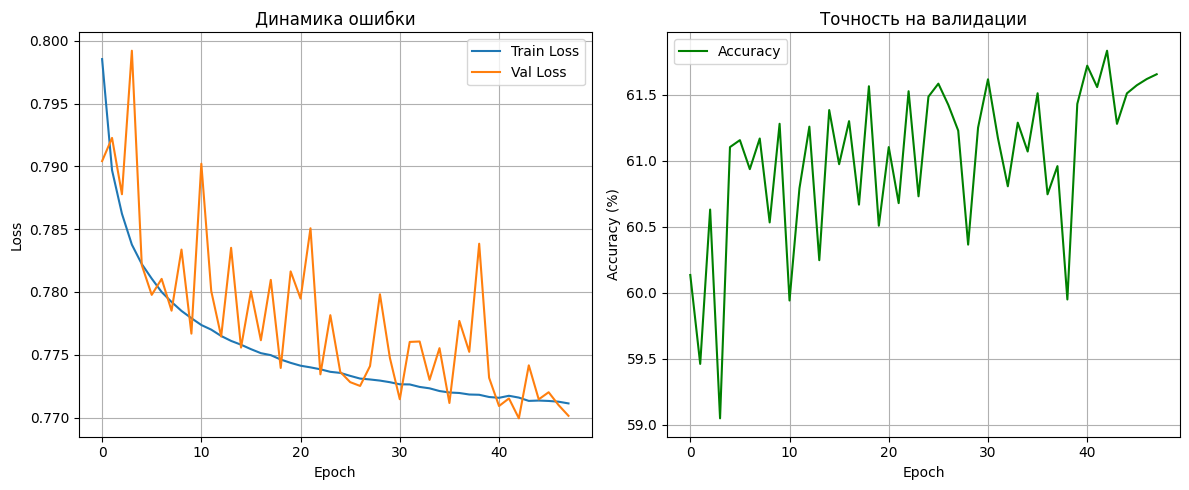

C:\Users\Mate Huslims\AppData\Local\Temp\ipykernel_19276\2505803486.py:32: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy_input, OUTPUT_MODEL, export_params=True, opset_version=11,
W0323 15:52:24.049166 19276 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Экспорт модели в ONNX...
[torch.onnx] Obtain model graph for `ChessNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ChessNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\Mate Huslims\AppData\Local\Programs\Python\Python310\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\Mate Huslims\Desktop\kchess\venv\lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "c:\Users\Mate Huslims\Desktop\kchess\venv\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\Mate Huslims\Desktop\kchess\venv\lib\site-packages\onnxscript\version_conver

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.
🎉 УСПЕХ! Модель сохранена в 'chess_model.onnx'
Теперь этот файл можно копировать в папку C# проекта.


In [19]:
# 1. Построение графиков
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика ошибки')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], color='green', label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Точность на валидации')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Экспорт в ONNX
print("Экспорт модели в ONNX...")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
model.to("cpu") # Экспортируем всегда с CPU для совместимости

dummy_input = torch.randn(1, 12, 8, 8)

torch.onnx.export(model, dummy_input, OUTPUT_MODEL, export_params=True, opset_version=11,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})

print(f"🎉 УСПЕХ! Модель сохранена в '{OUTPUT_MODEL}'")
print("Теперь этот файл можно копировать в папку C# проекта.")